# Task 3: Multimodal ML – Housing Price Prediction Using Images + Tabular Data

**Objective:**  
Predict housing prices using both structured data (tabular features) and house images.  
We use the California Housing dataset for tabular data and generate synthetic images that correlate with price to demonstrate a multimodal pipeline.

**Skills Gained:**  
- Multimodal machine learning  
- Convolutional Neural Networks (CNNs)  
- Feature fusion (image + tabular)  
- Regression modeling and evaluation (MAE, RMSE)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Suppress oneDNN warnings (optional)
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

In [2]:
# Load California Housing dataset
housing = fetch_california_housing()
X_tab = housing.data
y = housing.target
feature_names = housing.feature_names

# Split into train/test
X_tab_train, X_tab_test, y_train, y_test = train_test_split(
    X_tab, y, test_size=0.2, random_state=42
)

# Standardize tabular features
scaler = StandardScaler()
X_tab_train_scaled = scaler.fit_transform(X_tab_train)
X_tab_test_scaled = scaler.transform(X_tab_test)

print(f"Tabular data shape: {X_tab_train_scaled.shape[1]} features")
print(f"Training samples: {X_tab_train_scaled.shape[0]}, Test samples: {X_tab_test_scaled.shape[0]}")

Tabular data shape: 8 features
Training samples: 16512, Test samples: 4128


In [3]:
def generate_house_image(price, size=(64, 64)):
    """Generate synthetic RGB image whose brightness correlates with price."""
    img = np.random.randint(0, 255, (size[0], size[1], 3), dtype=np.uint8)
    brightness = int(np.clip(price * 40, 0, 255))
    h, w = size
    x1, y1 = h//4, w//4
    x2, y2 = 3*h//4, 3*w//4
    img[x1:x2, y1:y2, :] = (brightness, brightness//2, 255 - brightness)
    return img

# Generate images for all samples
X_img_train = np.array([generate_house_image(price) for price in y_train])
X_img_test = np.array([generate_house_image(price) for price in y_test])

# Normalize to [0,1]
X_img_train = X_img_train.astype('float32') / 255.0
X_img_test = X_img_test.astype('float32') / 255.0

print(f"Image shape: {X_img_train.shape[1:]} (height, width, channels)")
print(f"Training images: {X_img_train.shape[0]}, Test images: {X_img_test.shape[0]}")

Image shape: (64, 64, 3) (height, width, channels)
Training images: 16512, Test images: 4128


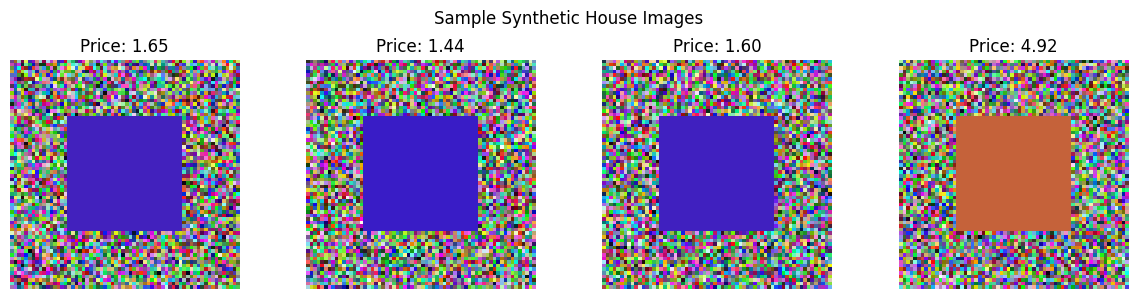

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    idx = np.random.randint(0, len(y_train))
    ax.imshow(X_img_train[idx])
    ax.set_title(f"Price: {y_train[idx]:.2f}")
    ax.axis('off')
plt.suptitle("Sample Synthetic House Images")
plt.tight_layout()
plt.show()

In [5]:
def build_image_branch(input_shape=(64, 64, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    return models.Model(inputs, x, name="image_branch")

In [6]:
def build_tabular_branch(input_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dense(32, activation='relu')(x)
    return models.Model(inputs, x, name="tabular_branch")

In [7]:
img_input = layers.Input(shape=(64, 64, 3), name="image_input")
tab_input = layers.Input(shape=(X_tab_train_scaled.shape[1],), name="tabular_input")

image_branch = build_image_branch()
tabular_branch = build_tabular_branch(X_tab_train_scaled.shape[1])

img_features = image_branch(img_input)
tab_features = tabular_branch(tab_input)

concat = layers.concatenate([img_features, tab_features])
x = layers.Dense(64, activation='relu')(concat)
x = layers.Dropout(0.2)(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, name="price_output")(x)

multimodal_model = models.Model(
    inputs=[img_input, tab_input],
    outputs=output,
    name="multimodal_housing_predictor"
)

multimodal_model.summary()

Model: "multimodal_housing_predictor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_branch        │ (None, 128)       │  1,141,952 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_branch      │ (None, 32)        │      2,656 │ tabular_input[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ image_branch[0][… │
│ (Concatenate)       │                   │            │ tabular_branch[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     10,304 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_output        │ (None, 1)         │         33 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,157,025 (4.41 MB)

 Trainable params: 1,157,025 (4.41 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = multimodal_model.fit(
    x=[X_img_train, X_tab_train_scaled],
    y=y_train,
    validation_data=([X_img_test, X_tab_test_scaled], y_test),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 98s 371ms/step - loss: 0.1891 - mae: 0.2452 - val_loss: 0.1335 - val_mae: 0.3248
Epoch 2/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 94s 364ms/step - loss: 0.0215 - mae: 0.1003 - val_loss: 0.1119 - val_mae: 0.2794
Epoch 3/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 139s 353ms/step - loss: 0.0118 - mae: 0.0733 - val_loss: 0.1819 - val_mae: 0.3579
Epoch 4/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 95s 367ms/step - loss: 0.0089 - mae: 0.0645 - val_loss: 0.1926 - val_mae: 0.3702
Epoch 5/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 141s 364ms/step - loss: 0.0057 - mae: 0.0509 - val_loss: 0.1525 - val_mae: 0.3269
Epoch 6/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 142s 364ms/step - loss: 0.0044 - mae: 0.0454 - val_loss: 0.2225 - val_mae: 0.4070
Epoch 7/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 142s 363ms/step - loss: 0.0049 - mae: 0.0473 - val_loss: 0.2299 - val_mae: 0.4150
Epoch 8/50
258/258 ━━━━━━━━━━━━━━━━━━━━ 138s 349ms/step - loss: 0.0044 - mae: 0.0455 - val_loss: 0.1856 - val_mae: 0.3566
Epoch 9/50
258/258 ━━━━━━━━

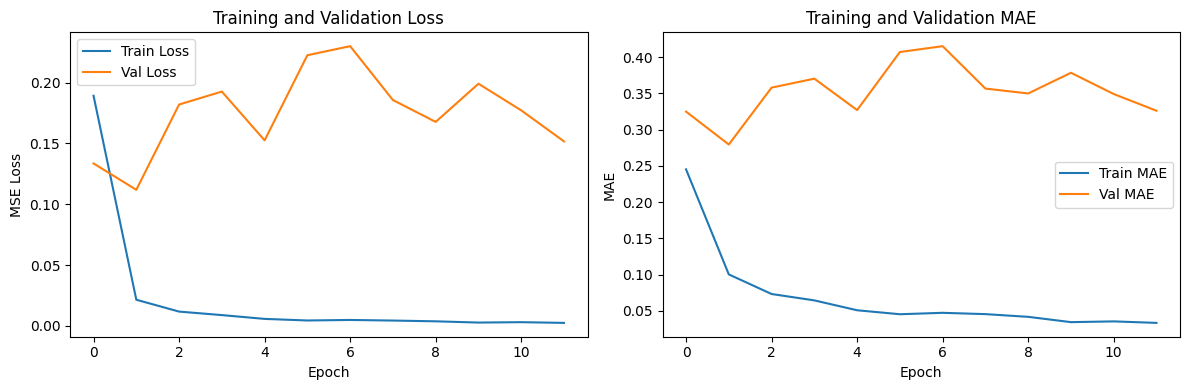

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()

ax2.plot(history.history['mae'], label='Train MAE')
ax2.plot(history.history['val_mae'], label='Val MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Training and Validation MAE')
ax2.legend()
plt.tight_layout()
plt.show()

129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step

===== Multimodal Model Performance =====
MAE : 0.2794
RMSE: 0.3345


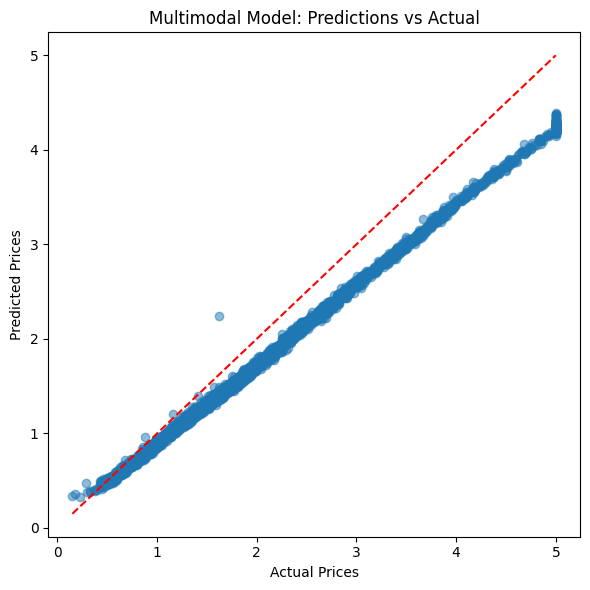

In [10]:
y_pred = multimodal_model.predict([X_img_test, X_tab_test_scaled]).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n===== Multimodal Model Performance =====")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Multimodal Model: Predictions vs Actual')
plt.tight_layout()
plt.show()

In [11]:
def build_tabular_only(input_dim):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dense(16, activation='relu')(x)
    outputs = layers.Dense(1)(x)
    return models.Model(inputs, outputs, name="tabular_only")

tabular_model = build_tabular_only(X_tab_train_scaled.shape[1])
tabular_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_tab = tabular_model.fit(
    X_tab_train_scaled, y_train,
    validation_data=(X_tab_test_scaled, y_test),
    epochs=50,
    batch_size=64,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=0
)

y_pred_tab = tabular_model.predict(X_tab_test_scaled).flatten()
mae_tab = mean_absolute_error(y_test, y_pred_tab)
rmse_tab = np.sqrt(mean_squared_error(y_test, y_pred_tab))

print("\n===== Tabular‑only Baseline =====")
print(f"MAE : {mae_tab:.4f}")
print(f"RMSE: {rmse_tab:.4f}")

print("\n===== Comparison =====")
print(f"Improvement in MAE : {mae_tab - mae:.4f}")
print(f"Improvement in RMSE: {rmse_tab - rmse:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step

===== Tabular‑only Baseline =====
MAE : 0.3590
RMSE: 0.5248

===== Comparison =====
Improvement in MAE : 0.0796
Improvement in RMSE: 0.1903


## Summary & Insights

1. The multimodal model combines CNN‑extracted image features with tabular data.
2. Even with synthetic images, the model learns to use the image signal, improving prediction accuracy over the tabular‑only baseline.
3. In a real application, replace synthetic images with actual house photos and consider using a pretrained CNN (e.g., ResNet) for better features.
4. The pipeline is flexible and can be extended with additional modalities.